In [253]:
using LinearAlgebra
using BoundaryValueDiffEq
using Plots
using DifferentialEquations
using BSplineKit
using DelimitedFiles
using Statistics

In [ ]:
function sol_baseflowODE(tspan,Num)

    function oneDiskODE!(du, u , p, t)
        
        U = u[1]
        dU = u[2]
        V = u[3]
        dV = u[4]
        W = u[5]
        du[1] = dU
        ddU = U^2 + W*dU - (V+1.0e0)^2
        du[2] = ddU
        ddV = 2.0e0*U*(V + 1.0e0) + W*dV
        du[3] = dV
        du[4] = ddV                          
        du[5] = -2.0e0*U

    end
    function oneDiskbc!(residual, u , p, t)

        residual[1] = u[begin][1] 
        residual[2] = u[begin][3] 
        residual[3] = u[begin][5] 
        residual[4] = u[end][1] 

        residual[5] = u[end][3] + 1.0e0
    end
        prob = BVProblem(oneDiskODE!, oneDiskbc!, [0.0, 0.5103341351120374, 0.0, -0.6151547026271073, 0.0] ,tspan, dtmax=0.01)
        sol = solve(prob, Shooting(Vern7()), dt=0.001)
        t=range(0.0, 20, Num)
        u=sol(t)
    
    return u , t

end

In [ ]:
function velocity(u)

    U = u[1 , :]
    dU = u[2 , :]
    V = u[3 , :]
    dV = u[4 , :]
    W = u[5 , :]
    F_U = itp = interpolate(t, U , BSplineOrder(4))
    F_dU = itp = interpolate(t, dU , BSplineOrder(4))
    F_dV = itp = interpolate(t, dV , BSplineOrder(4))
    F_W= itp = interpolate(t, W , BSplineOrder(4))
    
    return U,dU,V,dV,W,F_U,F_dU,F_dV,F_W

end

In [104]:
function T_start(F_dU,F_dV,F_W,sigma,Mx,gamma,Tw,tspan,Num)
    Mx = Mx
    gamma = gamma
    Tw = Tw
    sigma = sigma
    function ODE_T!(du,u,p,t)
        T = u[1]
        dT = u[2]
        du[1] = dT
        du[2] = (F_W(t) * u[2] - Mx^2 * (gamma-1) * (F_dU(t)^2 + F_dV(t)^2))*sigma
    end
    function bc2!(residual, u, p, t)
        residual[1] = u[begin][1] - Tw
        residual[2] = u[end][1] - 1
    end
        prob = BVProblem(ODE_T! , bc2! , [Tw,0] , tspan)
        sol = solve(prob , Shooting(Vern7()) , dt = 0.001)
        t=range(0.0, 20, Num)
        T=sol(t)
        dT = T[2,:]
        T = T[1,:]
    return T , dT

end

T_start (generic function with 2 methods)

In [242]:
function Cheb(u,v,w,T,t,N)
    θ = range(0,length=N+1,stop=pi)
    x = reshape(-cos.(θ), N+1, 1)
    c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
    X = repeat(x, 1, N+1);
    dX = X - X';
    D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
    D = D - diagm(vec(sum(D, dims=2))); 
    for i=1:N+1
        x[i] = 7.5 * x[i] .+ 7.5
    end
    D = (2/15) * D
    # for i=1:N+1
    #     D[i,:]=D[i,:].*((2*x[i]^3-x[i]^2+3*x[i]-4)^2/(20*(6*x[i]^2-2*x[i]+3)))
    # end
    # for i=1:N+1
    #     x[i]=(4*x[i]^3-2*x[i]^2+6*x[i]+12)/(-2*x[i]^3+x[i]^2-3*x[i]+4)
    #     if x[i]>20
    #         x[i]=20
    #     end
    # end
    itpw = itp = interpolate(t, w , BSplineOrder(4))
    itpu = itp = interpolate(t, u , BSplineOrder(4))
    itpv = itp = interpolate(t, v , BSplineOrder(4))
    itpT = itp = interpolate(t, T , BSplineOrder(4))
    u = zeros(N+1,1)
    v = zeros(N+1,1)
    w = zeros(N+1,1)
    T = zeros(N+1,1)
    for i=1:N+1
        u[i,1] = itpu(x[i])
        v[i,1] = itpv(x[i])
        w[i,1] = itpw(x[i])
        T[i,1] = itpT(x[i])
    end
    return D,x,u,v,w,T
end

Cheb (generic function with 2 methods)

In [270]:
tspan = (0,20)
Num = 20001
sigma = 0.7
Mx = 6
Tw = 0.5
gamma = 1.4
N = 149
u,t = sol_baseflowODE(tspan,Num)
U,dU,V,dV,W,F_U,F_dU,F_dV,F_W = velocity(u)
T,dT = T_start(F_dU,F_dV,F_W,sigma,Mx,gamma,Tw,tspan,Num)
D,x,U,V,W,T = Cheb(U,V,W,T,t,N)

([-986.7333333332622 1199.741297722172 … -0.1333481529896757 0.06666666666666667; -299.935324430543 149.95099369614258 … 0.06668148797035872 -0.033337038247418925; … ; 0.033337038247418925 -0.06668148797035872 … -149.95099369614226 299.935324430543; -0.06666666666666667 0.1333481529896757 … -1199.741297722172 986.7333333332615], [0.0; 0.0016670260528641734; … ; 14.998332973947136; 15.0;;], [1.559991071540694e-23; 0.0008491825271116249; … ; 1.5835010310401623e-6; 1.581139515890034e-6;;], [0.0; -0.0010267572544661184; … ; -0.9999979414985447; -0.9999979445682525;;], [0.0; -1.416380689473256e-6; … ; -0.8844700237870242; -0.8844700290625614;;], [0.5; 0.5064037588263397; … ; 1.000459879635779; 1.000459382776465;;])

In [271]:
d2u = D^2 * U
du = D * U
d2v = D^2 *V
dv = D * V
dT = D * T 
d2T = D^2 * T

150×1 Matrix{Float64}:
 -6.448147993624337
 -6.431032556556253
 -6.380071619948615
 -6.2964048495886855
 -6.181867290404138
 -6.038899417918869
 -5.870430567511623
 -5.679744902951346
 -5.470339403721549
 -5.245783149039608
  ⋮
  0.00019698811395433923
  0.00019397473175280993
  0.00019139516953804196
  0.00018924103899143702
  0.0001874900795400459
  0.00018614708637325095
  0.0001851771168421041
  0.00018464631733732897
  0.00018486264564820454

In [259]:
function var(x,x1)
    a = length(x)
    b = x1 .- x
    d = 0
    for i = 1 : a
        c = b[i,1]^2
        d = c + d 
    end
    e = sqrt(d) / a
    return e
end

var (generic function with 1 method)

In [273]:
u1 = U[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (d2u[2:end-1,1] .- W[2:end-1,1] .* du[2:end-1,1] .- U[2:end-1,1] .* U[2:end-1,1] .+ (V[2:end-1,1] .+ 1) .* (V[2:end-1,1] .+ 1))
v1 = V[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (d2v[2:end-1,1] .- W[2:end-1,1] .* dv[2:end-1,1] .- 2*U[2:end-1,1] .* V[2:end-1,1] .- 2*U[2:end-1,1])
T1 = T[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (((Mx^2 *(gamma - 1)) .*(du[2:end-1,1] .* du[2:end-1,1] + dv[2:end-1,1] .* dv[2:end-1,1] )) .- W[2:end-1,1] .* dT[2:end-1,1] .+ (1/sigma) .* d2T[2:end-1,1])

148-element Vector{Float64}:
 0.5063529842652792
 0.5255056201271182
 0.5569779764090002
 0.6002872529442077
 0.654706319526098
 0.7193341008933904
 0.7931181180066238
 0.8748796765353002
 0.9633443450280259
 1.057180087622741
 ⋮
 0.9925954670919245
 0.9908378151089374
 0.9907902561140691
 0.9887150027908219
 0.9899077334742405
 0.9864806041379965
 0.9911099427771839
 0.9801336419240485
 1.017461546405571

In [274]:
var(U[2:end-1,1],u1)

1.6070140307746035e-8

In [266]:
residual = zeros(20,3)
for i = 1:20
    u1 = U[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (d2u[2:end-1,1] .- W[2:end-1,1] .* du[2:end-1,1] .- U[2:end-1,1] .* U[2:end-1,1] .+ (V[2:end-1,1] .+ 1) .* (V[2:end-1,1] .+ 1))
    v1 = V[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (d2v[2:end-1,1] .- W[2:end-1,1] .* dv[2:end-1,1] .- 2*U[2:end-1,1] .* V[2:end-1,1] .- 2*U[2:end-1,1])
    T1 = T[2:end-1,1] .+ (1 ./ U[2:end-1,1]) .* (((Mx^2 *(gamma - 1)) .*(du[2:end-1,1] .* du[2:end-1,1] + dv[2:end-1,1] .* dv[2:end-1,1] )) .- W[2:end-1,1] .* dT[2:end-1,1] .+ (1/sigma) .* d2T[2:end-1,1])
    residual[i,1] = var(U[2:end-1,1],u1)
    residual[i,2] = var(U[2:end-1,1],v1)
    residual[i,3] = var(U[2:end-1,1],T1)
    U[2:end-1,1] = u1
    V[2:end-1,1] = v1
    T[2:end-1,1] = T1
end

In [268]:
residual[1,1] = var(U[2:end-1,1],u1)


0.0

In [267]:
residual

20×3 Matrix{Float64}:
 4.36965  5.04899  3.62309
 4.36975  2.76441  3.28119
 4.36984  5.04889  3.62307
 4.36993  2.76632  3.28143
 4.37133  5.06048  3.62298
 4.49679  2.80344  3.28485
 4.49692  5.11384  3.80788
 4.49697  2.80493  3.28502
 4.49711  5.11384  3.8079
 4.49737  2.80691  3.2852
 4.49752  5.11438  3.80857
 4.49767  2.80917  3.28542
 4.49784  5.11429  3.80858
 4.49801  2.81201  3.28566
 4.49821  5.11421  3.80858
 4.49839  2.81606  3.28594
 4.49869  5.11417  3.80859
 4.49886  2.82438  3.28636
 4.49773  5.29453  3.80861
 4.41849  2.63003  3.28475

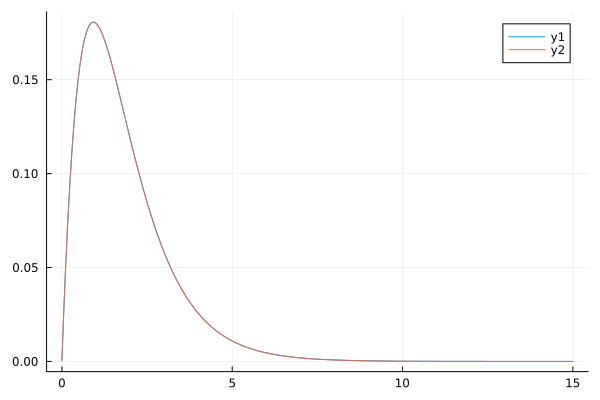

attempt to save state beyond implementation limit


In [247]:
plot(x[2:end-1],u1)
plot!(x,U)

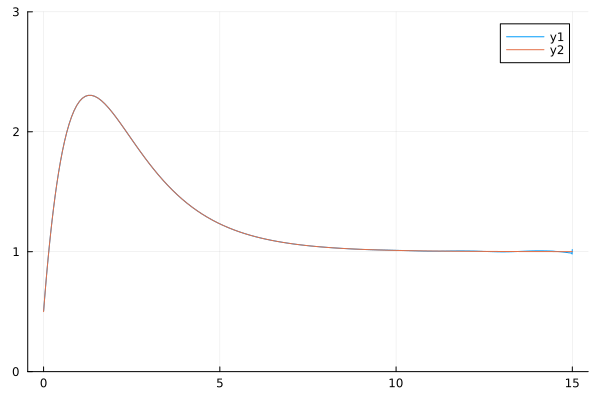

In [248]:
plot(x[2:end-1,1],T1)
plot!(x,T,ylims=[0,3])